Step 1: Create Dummy Data

In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Initialize empty list
data = []

# Dummy products/features
features = ['Chat', 'VideoCall', 'Search', 'Notifications', 'ProfileUpdate']

# Generate data for 1000 users
for user_id in range(1, 1001):
    # Signup date random in Jan 2026
    signup_date = datetime(2026,1,random.randint(1,28), random.randint(8,12), random.randint(0,59))
    data.append([user_id, 'signup', signup_date, ''])
    
    # Onboard 0-2 days after signup, 80% users complete
    if random.random() < 0.8:
        onboard_date = signup_date + timedelta(days=random.randint(0,2), hours=random.randint(0,5))
        data.append([user_id, 'onboard', onboard_date, ''])
        
        # Purchase 0-5 days after onboard, 60% of onboarded users purchase
        if random.random() < 0.6:
            purchase_date = onboard_date + timedelta(days=random.randint(0,5), hours=random.randint(0,5))
            data.append([user_id, 'purchase', purchase_date, ''])
            
            # Feature use: 1-5 random features used 1-3 times each
            for _ in range(random.randint(1,5)):
                feature = random.choice(features)
                feature_date = purchase_date + timedelta(days=random.randint(0,5), hours=random.randint(0,5))
                data.append([user_id, 'feature_use', feature_date, feature])

# Convert to DataFrame
df = pd.DataFrame(data, columns=['user_id','event','timestamp','product'])

# Save to CSV
df.to_csv('dummy_product_data.csv', index=False)
print("Dummy dataset created!")

Dummy dataset created!


In [2]:
df

,user_id,event,timestamp,product
0,1,signup,2026-01-05 08:40:00,
1,1,onboard,2026-01-07 11:40:00,
2,1,purchase,2026-01-07 12:40:00,
3,1,feature_use,2026-01-11 15:40:00,Notifications
4,1,feature_use,2026-01-12 17:40:00,Notifications
...,...,...,...,...
3835,996,signup,2026-01-09 10:51:00,
3836,997,signup,2026-01-03 09:09:00,
3837,998,signup,2026-01-14 08:24:00,
3838,999,signup,2026-01-19 09:21:00,


Step 2: Load the Data

In [3]:
import pandas as pd

data = pd.read_csv('dummy_product_data.csv')
print(data.head())

   user_id        event            timestamp        product
0        1       signup  2026-01-05 08:40:00            NaN
1        1      onboard  2026-01-07 11:40:00            NaN
2        1     purchase  2026-01-07 12:40:00            NaN
3        1  feature_use  2026-01-11 15:40:00  Notifications
4        1  feature_use  2026-01-12 17:40:00  Notifications


Step 3: Analyze the Funnel

In [5]:
# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Pivot table for funnel
funnel = data.pivot_table(index='user_id', columns='event', aggfunc='size', fill_value=0)

# Count users at each stage
total_signup = funnel['signup'].sum()
total_onboard = funnel['onboard'].sum()
total_purchase = funnel['purchase'].sum()

drop_signup_to_onboard = round((total_signup - total_onboard)/total_signup*100,2)
drop_onboard_to_purchase = round((total_onboard - total_purchase)/total_onboard*100,2)

print(f"Total Signups: {total_signup}")
print(f"Total Onboarded: {total_onboard}")
print(f"Total Purchased: {total_purchase}")
print(f"Drop-off Signup→Onboard: {drop_signup_to_onboard}%")
print(f"Drop-off Onboard→Purchase: {drop_onboard_to_purchase}%")

Total Signups: 1000
Total Onboarded: 826
Total Purchased: 492
Drop-off Signup→Onboard: 17.4%
Drop-off Onboard→Purchase: 40.44%


Step 4: Feature Analysis

In [6]:
# Top features used
top_features = data[data['event']=='feature_use']['product'].value_counts().head(5)
print(top_features)

product
Notifications    330
Search           310
VideoCall        302
ProfileUpdate    291
Chat             289
Name: count, dtype: int64


Step 5: Visualize Funnel 

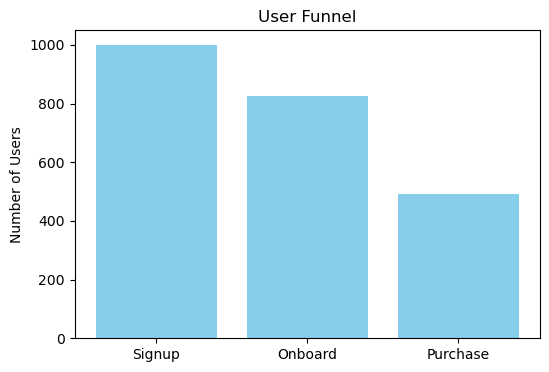

In [7]:
import matplotlib.pyplot as plt

stages = ['Signup', 'Onboard', 'Purchase']
users = [total_signup, total_onboard, total_purchase]

plt.figure(figsize=(6,4))
plt.bar(stages, users, color='skyblue')
plt.title('User Funnel')
plt.ylabel('Number of Users')
plt.show()

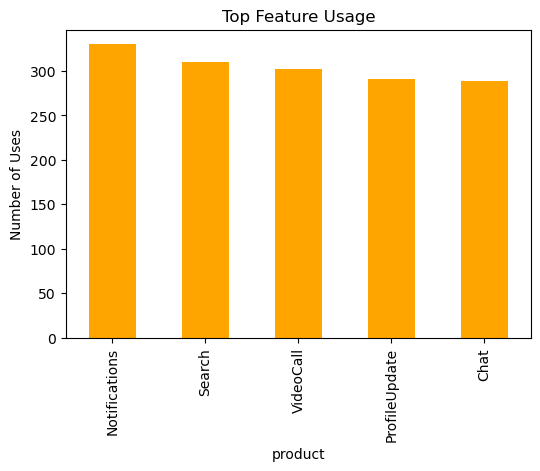

In [8]:
top_features.plot(kind='bar', color='orange', figsize=(6,4), title='Top Feature Usage')
plt.ylabel('Number of Uses')
plt.show()